In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cfeature
from cartopy.vector_transform import vector_scalar_to_grid
from matplotlib.axes import Axes
import metpy
import pint
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.units import units
import scipy as sp
from scipy.interpolate import RectBivariateSpline
import xarray as xr
from lagranto import Tra
import math
import datetime
from scipy.ndimage import rotate
import time
import iris
from iris.analysis.cartography import rotate_pole, rotate_winds
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from matplotlib.animation import FuncAnimation
import matplotlib.colors as mcolors

In [3]:
%run GEOS5functions.py
%matplotlib inline 

In [4]:
# Retrieve the list of all storms using the getallstorms function
stormlist = getallstorms()

# Set the current storm index to ???
currentstorm = 57

In [5]:
starttime = stormlist[3][currentstorm]
endtime   = stormlist[4][currentstorm]
lat1  = stormlist[5][currentstorm]
lat2  = stormlist[6][currentstorm]
lon1  = stormlist[7][currentstorm]
lon2  = stormlist[8][currentstorm]

timesel = slice(starttime,endtime)
extended_timesel = slice(starttime - datetime.timedelta(days=5) ,endtime + datetime.timedelta(days=5))
degbuffer = 20
latsel = slice(lat1-degbuffer,lat2+degbuffer)
lonsel = slice(lon1-degbuffer,lon2+degbuffer)

In [6]:
stormname = stormlist[1][currentstorm][0:9]
print(stormname)

npc05tc04


In [7]:
stormtraj = np.load('/home/z/zilmana/modares/TC/trajectory/' + str(stormname)+'.npz')
minpres = stormtraj['minpres']
timee = stormtraj['time']
minplat = stormtraj['minplat']
minplon = stormtraj['minplon']

In [8]:
ds = xr.open_dataset('extended_seri_so4_concentration_epc06tc01_box5.0_futures.nc')

In [9]:
ds['total_flux_da'].sel(lev = 41)

<xarray.DataArray 'total_flux_da' (time: 729)> Size: 3kB
[729 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 6kB 2006-05-26T06:30:00.000003 ... 2006-06...
    lev      float64 8B 41.0

In [10]:
ds

<xarray.Dataset> Size: 216kB
Dimensions:        (time: 729, lev: 72)
Coordinates:
  * time           (time) datetime64[ns] 6kB 2006-05-26T06:30:00.000003 ... 2...
  * lev            (lev) float64 576B 1.0 2.0 3.0 4.0 ... 69.0 70.0 71.0 72.0
Data variables:
    total_flux_da  (time, lev) float32 210kB ...

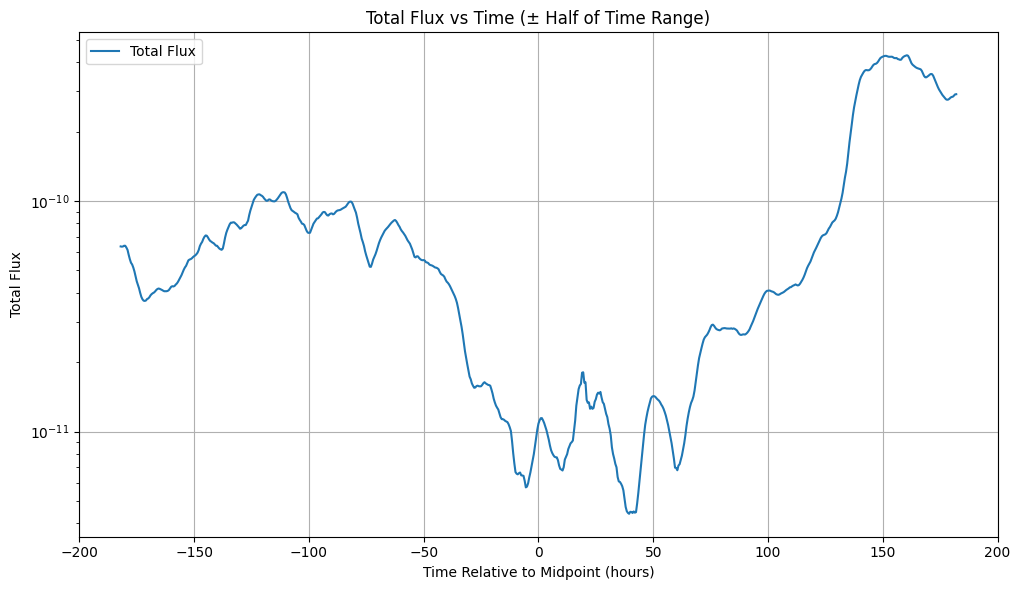

In [11]:
import matplotlib.pyplot as plt
import xarray as xr

# Assuming total_flux_da is your DataArray
# Extract time and values
time = ds['time'].values
flux = ds['total_flux_da'].sel(lev = 41).values

time_midpoint = time[len(time) // 2]  # Middle time point
time_shifted = (time - time_midpoint) / np.timedelta64(1, 'h')  # Convert to hours (or adjust unit as needed)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(time_shifted, flux, label='Total Flux')
plt.xlabel('Time Relative to Midpoint (hours)')
plt.ylabel('Total Flux')
plt.title('Total Flux vs Time (± Half of Time Range)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.yscale('log')

# Show the plot
plt.show()

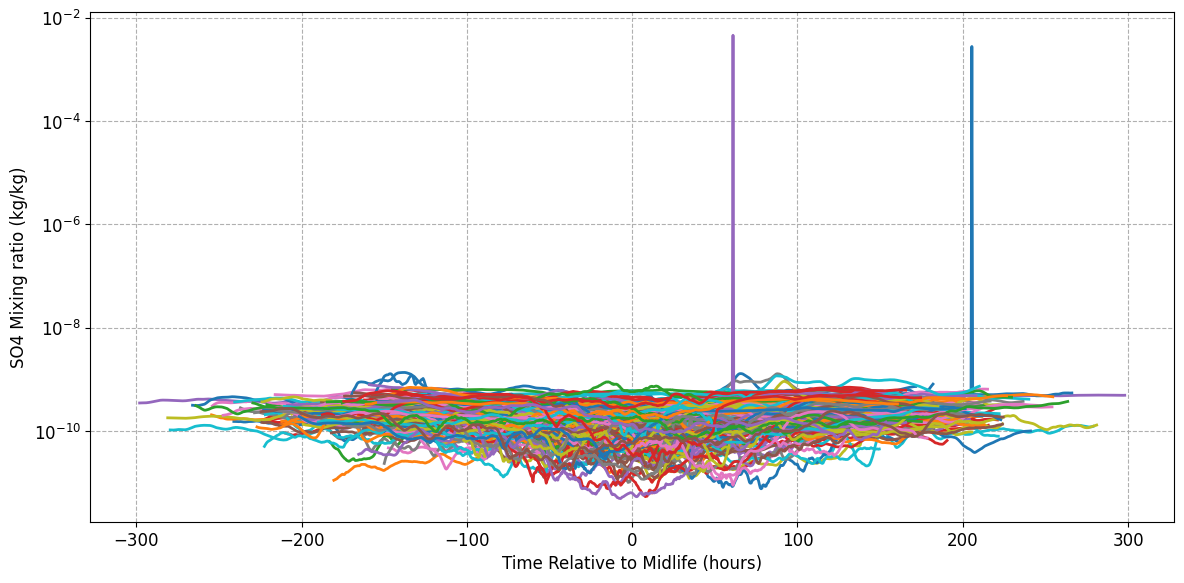

In [12]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import os

# Directory containing .nc files (update with your path)
directory = "."  # Adjust path as needed

# Get list of matching .nc files
matching_files = [f for f in os.listdir(directory) if f.startswith('extended_seri_so4_concentration_') and f.endswith('.nc')]

# Limit to first 20 files
matching_files = matching_files[:200]

# Set default font size
plt.rcParams.update({'font.size': 12})


# Initialize the plot
plt.figure(figsize=(12, 6))

# Loop through up to 20 matching files
for filename in matching_files:
    # Use a context manager to open the dataset
    file_path = os.path.join(directory, filename)
    with xr.open_dataset(file_path) as ds:
        # Extract total_flux_da DataArray
        total_flux_da = ds['total_flux_da']
        
        # Extract time and values
        time = total_flux_da['time'].values
        leve = 39
        flux = total_flux_da.sel(lev = leve).values
        
        # Shift time to center around midpoint
        time_midpoint = time[len(time) // 2]  # Middle time point
        time_shifted = (time - time_midpoint) / np.timedelta64(1, 'h')  # Convert to hours
        
        # Plot the data
        plt.plot(time_shifted, flux, alpha=1,linewidth=2, label=filename)

# Set logarithmic y-axis
plt.yscale('log')

# Add plot details
plt.xlabel('Time Relative to Midlife (hours)')
plt.ylabel('SO4 Mixing ratio (kg/kg)')
#plt.title('Spaghetti Plot of Total Flux vs Time (Up to 20 Files)')
plt.grid(True, which="both", ls="--")  # Grid for both major and minor ticks

# Add legend (since 20 files is reasonable for a legend)
#plt.legend()

plt.tight_layout()

# Save the plot (optional, remove if not needed)
plt.savefig(f'spaghetti_midlife_lev{leve}.png')

# Show the plot
plt.show()

aus56tc06
aus56tc03
nio06tc02
aus56tc10
npc05tc03
npc05tc11
aus56tc07
aus56tc01
aus56tc14
aus56tc11
npc06tc13
sio56tc04
aus67tc05
npc06tc16


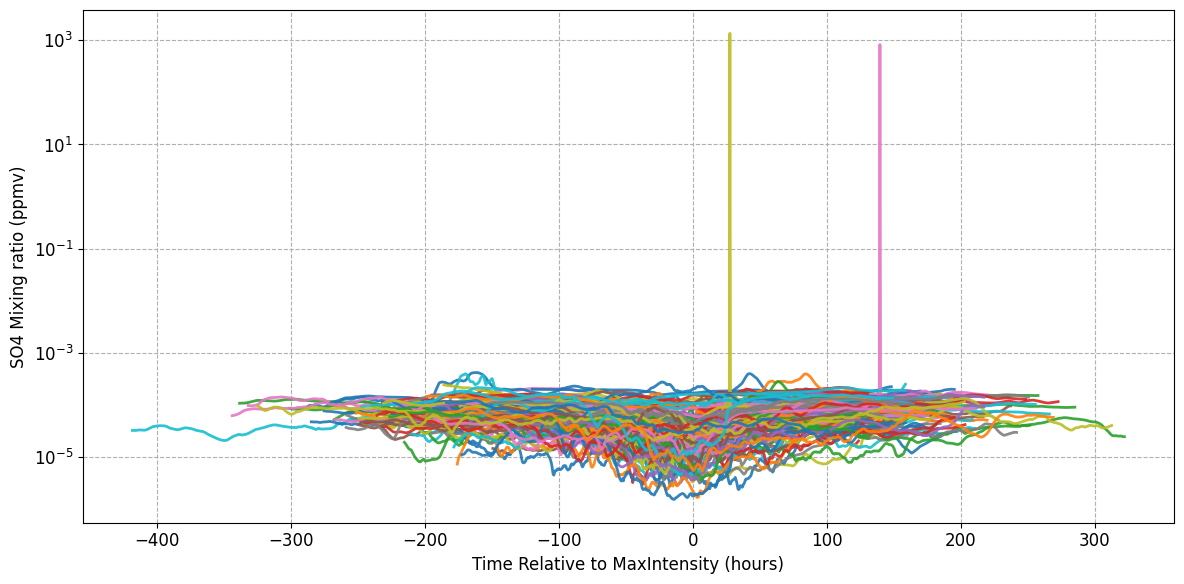

In [13]:


import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import os
import re

# Directory containing .nc files (update with your path)
directory = "."  # Adjust path as needed

# Get list of matching .nc files
matching_files = [f for f in os.listdir(directory) if f.startswith('extended_seri_so4_concentration') and f.endswith('.nc')]

# Limit to first 100 files
matching_files = matching_files[:200]

# Set default font size
plt.rcParams.update({'font.size': 12})

# Initialize the plot
plt.figure(figsize=(12, 6))

# Create N shades of gray from light to dark
n_files = len(matching_files)
#gray_colors = [str(0.4 + 0.0 * (i / (n_files - 1))) for i in range(n_files)]


# Loop through files
for i, filename in enumerate(matching_files):
    file_path = os.path.join(directory, filename)
    match = re.search(r'seri_so4_concentration_(.*?)_box', filename)
    
    if match:
        storm_name = match.group(1)
         
        stormtraj = np.load('/home/z/zilmana/modares/TC/trajectory/' + str(storm_name)+'.npz')
        minpres = stormtraj['minpres']
        timee = stormtraj['time']
        minplat = stormtraj['minplat']
        minplon = stormtraj['minplon']
    with xr.open_dataset(file_path) as ds:
        total_flux_da = ds['total_flux_da']
        time = total_flux_da['time'].values
        leve = 39
        flux = total_flux_da.sel(lev=leve).values

        if np.min(minpres) > 99000 : 
            print(storm_name)
            #print(np.min(minpres))

            continue


        t0_index = np.argmin(minpres)

        minplat_max = minplat[t0_index]
        #print(minplat_max)
        
        time_midpoint = time[t0_index + 240] 

        #print(time_midpoint)
        time_shifted = (time - time_midpoint) / np.timedelta64(1, 'h')
        
        # Increased line width to 1.5
        #plt.plot(time_shifted, flux, alpha=0.9, linewidth=2, color=gray_colors[i], label=filename)

        plt.plot(time_shifted, flux * (28.96/96.06) * 1e+6, alpha=0.9, linewidth=2, label=filename)

# Set logarithmic y-axis
plt.yscale('log')

# Add labels with font size 12 (automatically set by rcParams)
plt.xlabel('Time Relative to MaxIntensity (hours)')
plt.ylabel('SO4 Mixing ratio (ppmv)')
# plt.title('Spaghetti Plot of Total Flux vs Time (Up to 20 Files)')

plt.grid(True, which="both", ls="--")

# Uncomment if legend is needed
# plt.legend()

plt.tight_layout()
plt.savefig(f'so4_spaghetti_minpress_lev{leve}.png')
plt.show()

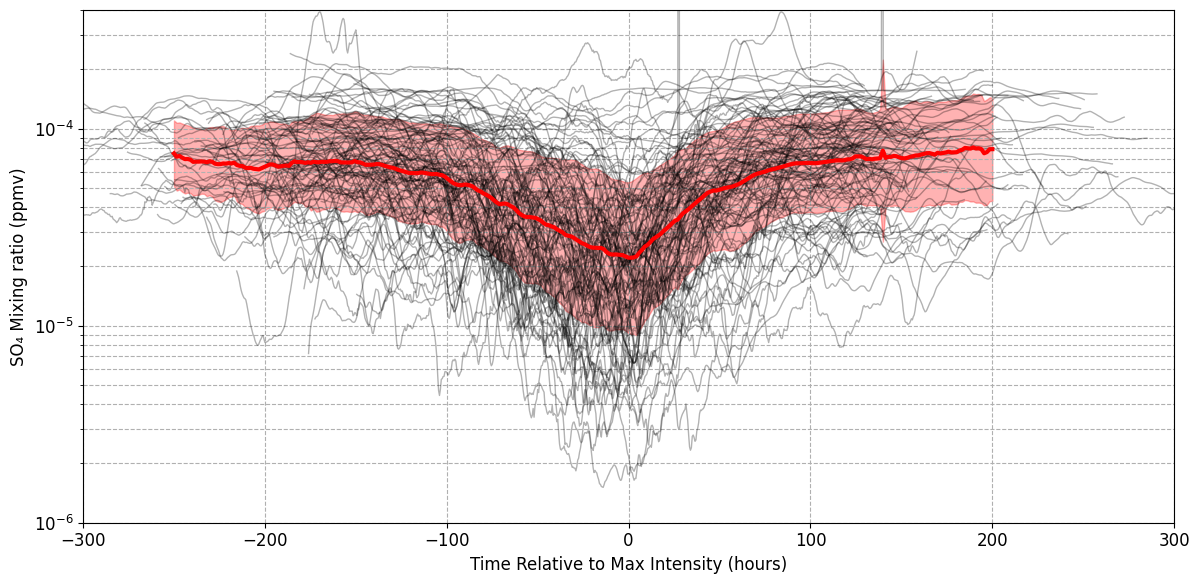

In [14]:
import os, re
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- collect all storm series ---
matching_files = [f for f in os.listdir('.') 
                  if f.startswith('extended_seri_so4_concentration') and f.endswith('.nc')][:200]

all_times = []
all_logflux = []
lev = 39

for fn in matching_files:
    m = re.search(r'extended_seri_so4_concentration_(.*?)_box', fn)
    if not m: 
        continue
    storm = m.group(1)
    traj = np.load(f'/home/z/zilmana/modares/TC/trajectory/{storm}.npz')
    pres = traj['minpres']
    t0 = np.argmin(pres)
    if np.min(pres) > 97000:
        continue

    with xr.open_dataset(fn) as ds:
        da = ds['total_flux_da'].sel(lev=lev)
        times = da['time'].values
        flux = da.values * (28.96/96.06)*1e6

    t_mid = times[t0 + 240]
    t_rel = (times - t_mid) / np.timedelta64(1, 'h')

    if len(t_rel) < 50:
        continue

    all_times.append(t_rel)
    all_logflux.append(np.log(flux))

# --- common grid (fixed window example) ---
common_t = np.linspace(-250, 200, 300)

# --- interpolate ---
interp_logs = []
for t_rel, logf in zip(all_times, all_logflux):
    f = interp1d(t_rel, logf, kind='cubic',
                 bounds_error=False, fill_value=np.nan)
    interp_logs.append(f(common_t))
interp_logs = np.vstack(interp_logs)    # shape = (n_storms, 300)

# --- compute mean and std in log-space ---
mean_log = np.nanmean(interp_logs, axis=0)
std_log  = np.nanstd(interp_logs, axis=0)

# back-transform to linear space
trend_flux = np.exp(mean_log)
upper_flux = np.exp(mean_log + std_log)
lower_flux = np.exp(mean_log - std_log)

# --- plot ---
plt.figure(figsize=(12,6))

# spaghetti
for t_rel, logf in zip(all_times, all_logflux):
    plt.plot(t_rel, np.exp(logf),  alpha=0.3, lw=1, color='black')

# shaded ±1σ envelope
plt.fill_between(common_t, lower_flux, upper_flux, 
                 color='red', alpha=0.3)

# mean trend
plt.plot(common_t, trend_flux, color='red', lw=3)

plt.yscale('log')
plt.xlabel('Time Relative to Max Intensity (hours)')
plt.ylabel('SO₄ Mixing ratio (ppmv)')
#plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.xlim(-300, 300)  # Show from 100h before to 100h after max intensity
plt.ylim(1 * 1e-6, 4 * 1e-4)

plt.savefig(f'so4_spaghetti_minpress_lev{leve}_trend.png')
plt.show()


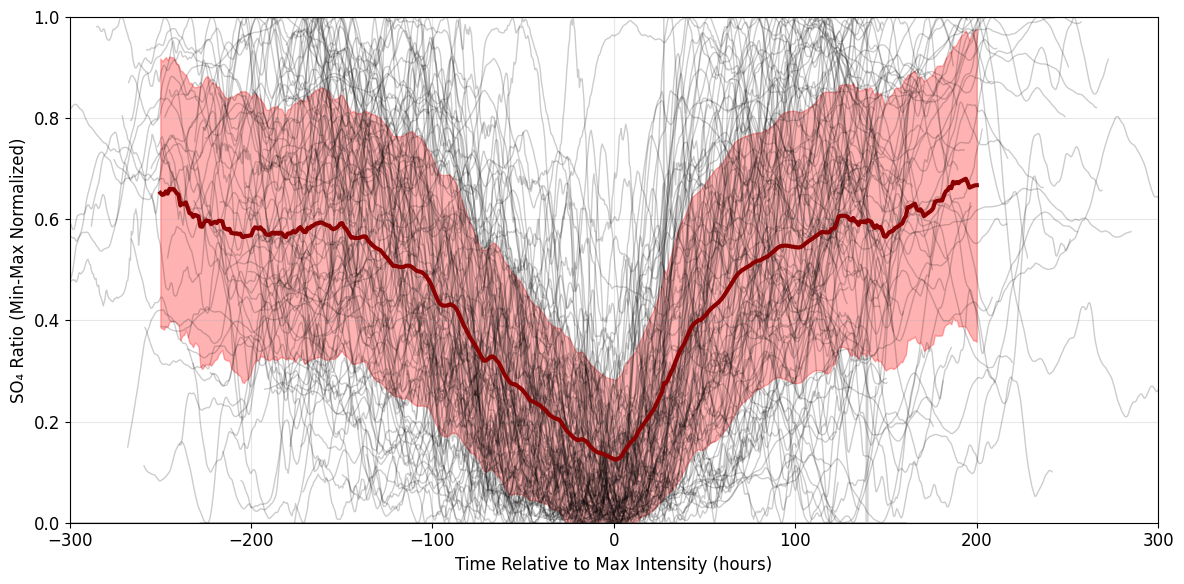

In [15]:
import os, re
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.gridspec import GridSpec

# --- collect all storm series ---
matching_files = [f for f in os.listdir('.') 
                  if f.startswith('extended_seri_so4_concentration') and f.endswith('.nc')][:200]
all_times = []
all_logflux = []
lev = 39
for fn in matching_files:
    m = re.search(r'extended_seri_so4_concentration_(.*?)_box', fn)
    if not m: 
        continue
    storm = m.group(1)
    traj = np.load(f'/home/z/zilmana/modares/TC/trajectory/{storm}.npz')
    pres = traj['minpres']
    t0 = np.argmin(pres)
    if np.min(pres) > 97000:
        continue
    with xr.open_dataset(fn) as ds:
        da = ds['total_flux_da'].sel(lev=lev)
        times = da['time'].values
        flux = da.values * (28.96/96.06)*1e6
    t_mid = times[t0 + 240]
    t_rel = (times - t_mid) / np.timedelta64(1, 'h')
    if len(t_rel) < 50:
        continue
    all_times.append(t_rel)
    all_logflux.append(np.log(flux))

# --- common grid (fixed window example) ---
common_t = np.linspace(-250, 200, 450)

# --- interpolate original data ---
interp_logs = []
for t_rel, logf in zip(all_times, all_logflux):
    f = interp1d(t_rel, logf, kind='cubic',
                 bounds_error=False, fill_value=np.nan)
    interp_logs.append(f(common_t))
interp_logs = np.vstack(interp_logs)    # shape = (n_storms, 300)

# --- compute mean and std in log-space ---
mean_log = np.nanmean(interp_logs, axis=0)
std_log = np.nanstd(interp_logs, axis=0)
# back-transform to linear space
trend_flux = np.exp(mean_log)
upper_flux = np.exp(mean_log + std_log)
lower_flux = np.exp(mean_log - std_log)

# --- NORMALIZE THE DATA ---
# Example: Normalize by maximum value for each storm
norm_method = "minmax"  # Options: "max", "baseline", "zscore", "minmax", "t0", "rolling"

normalized_values = []
normalized_interp = []

for i, (t_rel, logf) in enumerate(zip(all_times, all_logflux)):
    flux = np.exp(logf)  # Convert to linear space
    
    if norm_method == "max":
        # Normalize by maximum value
        max_flux = np.nanmax(flux)
        norm_flux = flux / max_flux
        
    elif norm_method == "baseline":
        # Normalize by pre-storm baseline (first 5 points)
        sorted_indices = np.argsort(t_rel)
        n_baseline_pts = min(240, len(sorted_indices))
        baseline = np.nanmean(flux[sorted_indices[:n_baseline_pts]])
        norm_flux = flux / baseline
        
    elif norm_method == "zscore":
        # Z-score normalization
        mean_flux = np.nanmean(flux)
        std_flux = np.nanstd(flux)
        norm_flux = (flux - mean_flux) / std_flux
        
    elif norm_method == "minmax":
        # Min-max scaling to [0,1]
        min_flux = np.nanmin(flux)
        max_flux = np.nanmax(flux)
        if max_flux > min_flux:  # Prevent division by zero
            norm_flux = (flux - min_flux) / (max_flux - min_flux)
        else:
            norm_flux = np.ones_like(flux)
            
    elif norm_method == "t0":
        # Normalize relative to time of max intensity (t≈0)
        t0_idx = np.argmin(np.abs(t_rel))
        t0_flux = flux[t0_idx]
        norm_flux = flux / t0_flux
        
    elif norm_method == "rolling":
        # Normalize by rolling average
        from scipy.ndimage import uniform_filter1d
        window = min(len(flux) // 4, 200)
        smoothed = uniform_filter1d(flux, size=window)
        norm_flux = flux / smoothed
    
    normalized_values.append(norm_flux)
    
    # Interpolate normalized values to common time grid
    f_norm = interp1d(t_rel, norm_flux, kind='cubic',
                     bounds_error=False, fill_value=np.nan)
    normalized_interp.append(f_norm(common_t))

normalized_interp = np.vstack(normalized_interp)

# Calculate statistics for normalized data
norm_mean = np.nanmean(normalized_interp, axis=0)
norm_std = np.nanstd(normalized_interp, axis=0)
norm_upper = norm_mean + norm_std
norm_lower = norm_mean - norm_std

# --- CREATE FIGURE WITH TWO SUBPLOTS ---
# --- Create and save original plot ---
# --- Create and save normalized plot ---
plt.figure(figsize=(12, 6))
# Plot normalized spaghetti lines
for t_rel, norm_flux in zip(all_times, normalized_values):
    plt.plot(t_rel, norm_flux, alpha=0.2, lw=1, color='black')
# Plot normalized mean and std
plt.fill_between(common_t, norm_lower, norm_upper, 
                color='red', alpha=0.3)
plt.plot(common_t, norm_mean, color='darkred', lw=3, label='Mean')

# Set y-scale based on normalization method
if norm_method in ["max", "baseline", "t0"]:
    # Ratios often benefit from log scale
    plt.yscale('linear')
    ylabel = f'SO₄ Ratio (Normalized by {norm_method})'
    # Set y limits appropriate for ratio data (adjust as needed)
    plt.ylim(0, 2)  # Shows one order of magnitude in each direction
elif norm_method == "zscore":
    # Z-scores should be on linear scale
    plt.yscale('linear')
    ylabel = 'SO₄ Z-score'
    # Set y limits appropriate for z-scores
    plt.ylim(-3, 3)  # ±3 standard deviations typically captures most variation
elif norm_method == "minmax":
    plt.yscale('linear')
    ylabel = 'SO₄ Ratio (Min-Max Normalized)'
    # Min-max scaling produces values between 0 and 1
    plt.ylim(0, 1)  # Slight margin above 1 for visibility
elif norm_method == "rolling":
    plt.yscale('linear')
    ylabel = 'SO₄ / Rolling Average'
    # Set reasonable limits for ratio to rolling average
    plt.ylim(0.5, 1.5)  # ±50% variation from rolling average

# Set x limits to focus on the period of interest
plt.xlim(-300, 300)  # Show from 100h before to 100h after max intensity

# Add horizontal line at y=1 for ratio methods
if norm_method in ["max", "baseline", "t0", "rolling"]:
    plt.axhline(y=1, color='k', linestyle='--', alpha=0.5)
# Add horizontal line at y=0 for z-score
if norm_method == "zscore":
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)

plt.xlabel('Time Relative to Max Intensity (hours)')
plt.ylabel(ylabel)
#plt.title(f'Normalized SO₄ Values ({norm_method.capitalize()} Method)')
#plt.axvline(x=0, color='k', linestyle='--', alpha=0.5, label='Max Intensity')
#plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Save normalized plot
plt.savefig(f'so4_{norm_method}_normalized_values_lev{lev}.png')


-228.0
192.99999999916668


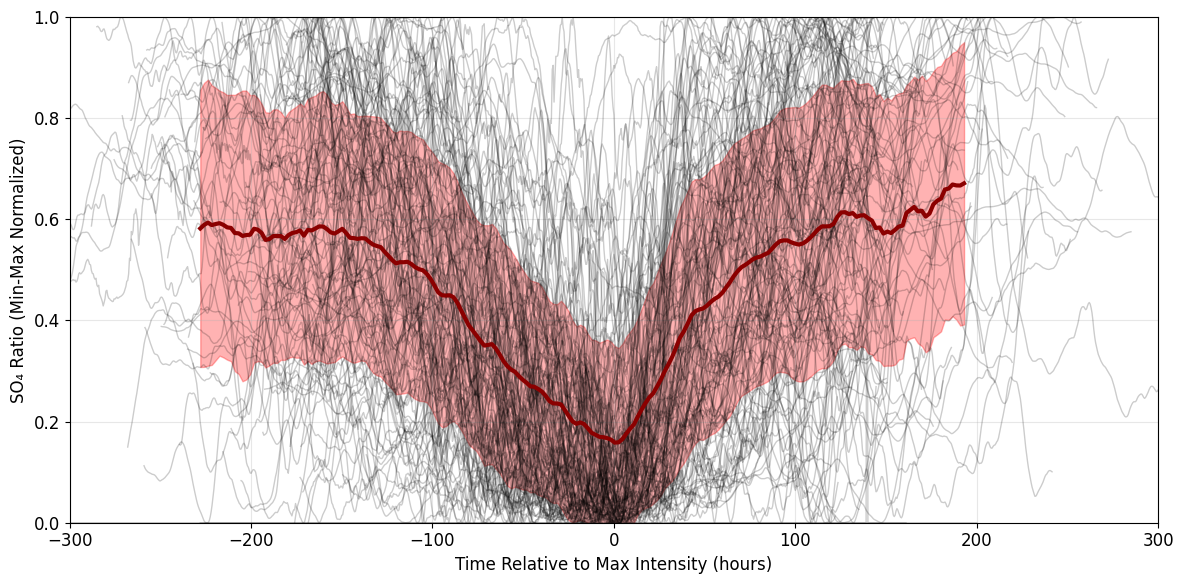

In [16]:
import os, re
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.gridspec import GridSpec

# --- collect all storm series ---
matching_files = [f for f in os.listdir('.') 
                  if f.startswith('extended_seri_so4_concentration') and f.endswith('.nc')][:200]
all_times = []
all_logflux = []
lev = 39
for fn in matching_files:
    m = re.search(r'extended_seri_so4_concentration_(.*?)_box', fn)
    if not m: 
        continue
    storm = m.group(1)
    traj = np.load(f'/home/z/zilmana/modares/TC/trajectory/{storm}.npz')
    pres = traj['minpres']
    t0 = np.argmin(pres)
    if np.min(pres) > 99000:
        continue
    with xr.open_dataset(fn) as ds:
        da = ds['total_flux_da'].sel(lev=lev)
        times = da['time'].values
        flux = da.values 
    t_mid = times[t0 + 240]
    t_rel = (times - t_mid) / np.timedelta64(1, 'h')
    if len(t_rel) < 50:
        continue
    all_times.append(t_rel)
    all_logflux.append(np.log(flux))

smallest_values = [np.min(t_rel) for t_rel in all_times]
largest_values = [np.max(t_rel) for t_rel in all_times]
sorted_smallest = sorted(smallest_values)
sorted_largest = sorted(largest_values)

quarter_index = len(sorted_smallest) // 4  # or use math.floor(n * 0.25)
threequarter_index = 3 *len(sorted_largest) // 4 


# Value and index (argument)
value_min = sorted_smallest[quarter_index]
value_max = sorted_largest[threequarter_index]
print(value_min)
print(value_max)

common_t = np.linspace(value_min, value_max, 200)
###

# --- interpolate original data ---
interp_logs = []
for t_rel, logf in zip(all_times, all_logflux):
    f = interp1d(t_rel, logf, kind='cubic',
                 bounds_error=False, fill_value=np.nan)
    interp_logs.append(f(common_t))
interp_logs = np.vstack(interp_logs)    # shape = (n_storms, 300)

# --- compute mean and std in log-space ---
mean_log = np.nanmean(interp_logs, axis=0)
std_log = np.nanstd(interp_logs, axis=0)
# back-transform to linear space
trend_flux = np.exp(mean_log)
upper_flux = np.exp(mean_log + std_log)
lower_flux = np.exp(mean_log - std_log)

# --- NORMALIZE THE DATA ---
# Example: Normalize by maximum value for each storm
norm_method = "minmax"  # Options: "max", "baseline", "zscore", "minmax", "t0", "rolling"

normalized_values = []
normalized_interp = []

for i, (t_rel, logf) in enumerate(zip(all_times, all_logflux)):
    flux = np.exp(logf)  # Convert to linear space
    
    if norm_method == "max":
        # Normalize by maximum value
        max_flux = np.nanmax(flux)
        norm_flux = flux / max_flux
        
    elif norm_method == "baseline":
        # Normalize by pre-storm baseline (first 5 points)
        sorted_indices = np.argsort(t_rel)
        n_baseline_pts = min(240, len(sorted_indices))
        baseline = np.nanmean(flux[sorted_indices[:n_baseline_pts]])
        norm_flux = flux / baseline
        
    elif norm_method == "zscore":
        # Z-score normalization
        mean_flux = np.nanmean(flux)
        std_flux = np.nanstd(flux)
        norm_flux = (flux - mean_flux) / std_flux
        
    elif norm_method == "minmax":
        # Min-max scaling to [0,1]
        min_flux = np.nanmin(flux)
        max_flux = np.nanmax(flux)
        if max_flux > min_flux:  # Prevent division by zero
            norm_flux = (flux - min_flux) / (max_flux - min_flux)
        else:
            norm_flux = np.ones_like(flux)
            
    elif norm_method == "t0":
        # Normalize relative to time of max intensity (t≈0)
        t0_idx = np.argmin(np.abs(t_rel))
        t0_flux = flux[t0_idx]
        norm_flux = flux / t0_flux
        
    elif norm_method == "rolling":
        # Normalize by rolling average
        from scipy.ndimage import uniform_filter1d
        window = min(len(flux) // 4, 200)
        smoothed = uniform_filter1d(flux, size=window)
        norm_flux = flux / smoothed
    
    normalized_values.append(norm_flux)
    
    # Interpolate normalized values to common time grid
    f_norm = interp1d(t_rel, norm_flux, kind='cubic',
                     bounds_error=False, fill_value=np.nan)
    normalized_interp.append(f_norm(common_t))

normalized_interp = np.vstack(normalized_interp)

# Calculate statistics for normalized data
norm_mean = np.nanmean(normalized_interp, axis=0)
norm_std = np.nanstd(normalized_interp, axis=0)
norm_upper = norm_mean + norm_std
norm_lower = norm_mean - norm_std

# --- CREATE FIGURE WITH TWO SUBPLOTS ---
# --- Create and save original plot ---
# --- Create and save normalized plot ---
plt.figure(figsize=(12, 6))
# Plot normalized spaghetti lines
for t_rel, norm_flux in zip(all_times, normalized_values):
    plt.plot(t_rel, norm_flux, alpha=0.2, lw=1, color='black')
# Plot normalized mean and std
plt.fill_between(common_t, norm_lower, norm_upper, 
                color='red', alpha=0.3)
plt.plot(common_t, norm_mean, color='darkred', lw=3, label='Mean')

# Set y-scale based on normalization method
if norm_method in ["max", "baseline", "t0"]:
    # Ratios often benefit from log scale
    plt.yscale('linear')
    ylabel = f'SO₄ Ratio (Normalized by {norm_method})'
    # Set y limits appropriate for ratio data (adjust as needed)
    plt.ylim(0, 2)  # Shows one order of magnitude in each direction
elif norm_method == "zscore":
    # Z-scores should be on linear scale
    plt.yscale('linear')
    ylabel = 'SO₄ Z-score'
    # Set y limits appropriate for z-scores
    plt.ylim(-3, 3)  # ±3 standard deviations typically captures most variation
elif norm_method == "minmax":
    plt.yscale('linear')
    ylabel = 'SO₄ Ratio (Min-Max Normalized)'
    # Min-max scaling produces values between 0 and 1
    plt.ylim(0, 1)  # Slight margin above 1 for visibility
elif norm_method == "rolling":
    plt.yscale('linear')
    ylabel = 'SO₄ / Rolling Average'
    # Set reasonable limits for ratio to rolling average
    plt.ylim(0.5, 1.5)  # ±50% variation from rolling average

# Set x limits to focus on the period of interest
plt.xlim(-300, 300)  # Show from 100h before to 100h after max intensity

# Add horizontal line at y=1 for ratio methods
if norm_method in ["max", "baseline", "t0", "rolling"]:
    plt.axhline(y=1, color='k', linestyle='--', alpha=0.5)
# Add horizontal line at y=0 for z-score
if norm_method == "zscore":
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)

plt.xlabel('Time Relative to Max Intensity (hours)')
plt.ylabel(ylabel)
#plt.title(f'Normalized SO₄ Values ({norm_method.capitalize()} Method)')
#plt.axvline(x=0, color='k', linestyle='--', alpha=0.5, label='Max Intensity')
#plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Save normalized plot
plt.savefig(f'so4_{norm_method}_normalized_values_lev{lev}.png')


# categorising

In [33]:
import pandas as pd

def is_cat(storm_name):
    """
    Checks if a given storm name is Category 4 or 5 based on the CSV file.

    Parameters:
        storm_name (str): The storm name to check.
        csv_path (str): Path to the CSV file.

    Returns:
        bool: True if the storm is Category 4 or 5, False otherwise.
    """
    df = pd.read_csv('paralel_storm_classification_results_alltimes.csv')

    # Normalize column names and data
    df.columns = df.columns.str.strip().str.lower()
    df['storm_name'] = df['storm_name'].str.strip().str.lower()
    df['category'] = df['category'].str.strip().str.lower()

    # Check if the storm is Cat 4 or 5
    mask = (df['storm_name'] == storm_name.lower()) & (
        df['category'].isin(['category 3 hurricane'])
    )

    return mask.any()


atl06tc07
1
sio67tc03
sio67tc03 is not Category. Exiting loop.
atl05tc10
atl05tc10 is not Category. Exiting loop.
npc05tc19
npc05tc19 is not Category. Exiting loop.
npc06tc02
2
atl06tc10
3
npc06tc07
npc06tc07 is not Category. Exiting loop.
sio56tc13
4
aus56tc04
aus56tc04 is not Category. Exiting loop.
aus56tc09
aus56tc09 is not Category. Exiting loop.
npc06tc06
npc06tc06 is not Category. Exiting loop.
epc06tc06
5
epc05tc02
6
npc06tc11
npc06tc11 is not Category. Exiting loop.
epc06tc11
epc06tc11 is not Category. Exiting loop.
aus56tc12
aus56tc12 is not Category. Exiting loop.
npc05tc18
npc05tc18 is not Category. Exiting loop.
atl06tc06
7
atl05tc13
atl05tc13 is not Category. Exiting loop.
epc06tc15
epc06tc15 is not Category. Exiting loop.
npc06tc01
npc06tc01 is not Category. Exiting loop.
aus56tc06
aus56tc06 is not Category. Exiting loop.
epc06tc05
epc06tc05 is not Category. Exiting loop.
atl05tc01
8
epc05tc04
epc05tc04 is not Category. Exiting loop.
epc05tc07
epc05tc07 is not Category. 

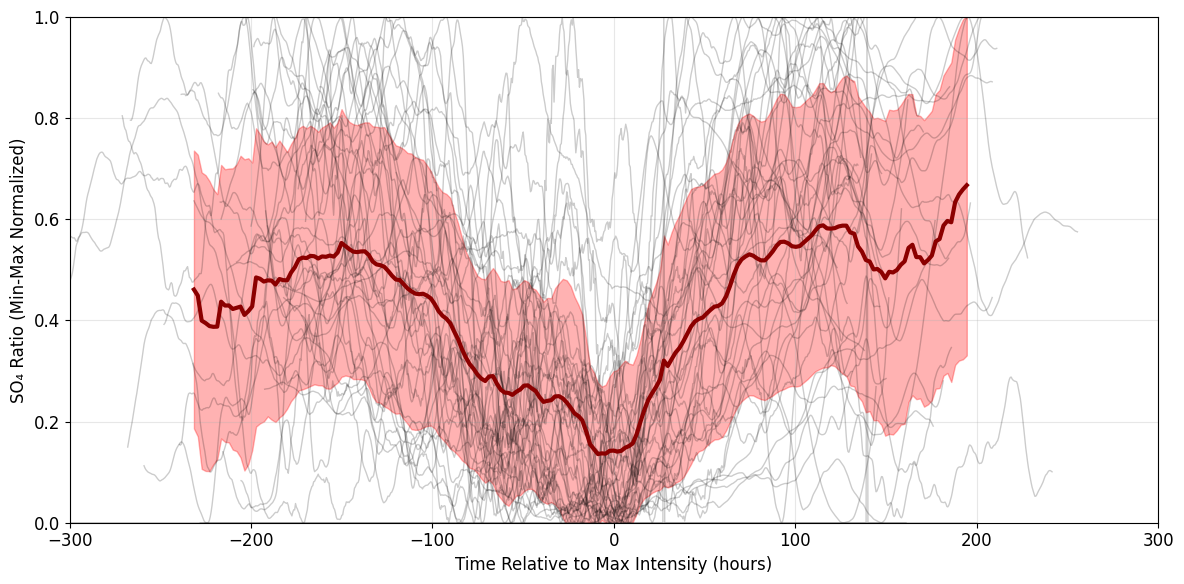

In [34]:
import os, re
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.gridspec import GridSpec

# --- collect all storm series ---
matching_files = [f for f in os.listdir('.') 
                  if f.startswith('extended_seri_so4_concentration') and f.endswith('.nc')][:200]
all_times = []
all_logflux = []
lev = 39
counter = 0
for fn in matching_files:
    m = re.search(r'extended_seri_so4_concentration_(.*?)_box', fn)
    if not m: 
        continue
    storm = m.group(1)
    print(storm)
    if not is_cat(storm):
        print(f"{storm} is not Category. Exiting loop.")
        continue
    counter = counter + 1
    print(counter)
    traj = np.load(f'/home/z/zilmana/modares/TC/trajectory/{storm}.npz')
    pres = traj['minpres']
    t0 = np.argmin(pres)
    with xr.open_dataset(fn) as ds:
        da = ds['total_flux_da'].sel(lev=lev)
        times = da['time'].values
        flux = da.values 
    t_mid = times[t0 + 240]
    t_rel = (times - t_mid) / np.timedelta64(1, 'h')
    if len(t_rel) < 50:
        continue
    all_times.append(t_rel)
    all_logflux.append(np.log(flux))

# --- common grid (fixed window example) ---
smallest_values = [np.min(t_rel) for t_rel in all_times]
largest_values = [np.max(t_rel) for t_rel in all_times]
sorted_smallest = sorted(smallest_values)
sorted_largest = sorted(largest_values)

quarter_index = len(sorted_smallest) // 4  # or use math.floor(n * 0.25)
threequarter_index = 3 *len(sorted_largest) // 4 


# Value and index (argument)
value_min = sorted_smallest[quarter_index]
value_max = sorted_largest[threequarter_index]
print(value_min)
print(value_max)

common_t = np.linspace(value_min, value_max, 200)
###

# --- interpolate original data ---
interp_logs = []
for t_rel, logf in zip(all_times, all_logflux):
    f = interp1d(t_rel, logf, kind='cubic',
                 bounds_error=False, fill_value=np.nan)
    interp_logs.append(f(common_t))
interp_logs = np.vstack(interp_logs)    # shape = (n_storms, 300)

# --- compute mean and std in log-space ---
mean_log = np.nanmean(interp_logs, axis=0)
std_log = np.nanstd(interp_logs, axis=0)
# back-transform to linear space
trend_flux = np.exp(mean_log)
upper_flux = np.exp(mean_log + std_log)
lower_flux = np.exp(mean_log - std_log)

# --- NORMALIZE THE DATA ---
# Example: Normalize by maximum value for each storm
norm_method = "minmax"  # Options: "max", "baseline", "zscore", "minmax", "t0", "rolling"

normalized_values = []
normalized_interp = []

for i, (t_rel, logf) in enumerate(zip(all_times, all_logflux)):
    flux = np.exp(logf)  # Convert to linear space
    
    if norm_method == "max":
        # Normalize by maximum value
        max_flux = np.nanmax(flux)
        norm_flux = flux / max_flux
        
    elif norm_method == "baseline":
        # Normalize by pre-storm baseline (first 5 points)
        sorted_indices = np.argsort(t_rel)
        n_baseline_pts = min(240, len(sorted_indices))
        baseline = np.nanmean(flux[sorted_indices[:n_baseline_pts]])
        norm_flux = flux / baseline
        
    elif norm_method == "zscore":
        # Z-score normalization
        mean_flux = np.nanmean(flux)
        std_flux = np.nanstd(flux)
        norm_flux = (flux - mean_flux) / std_flux
        
    elif norm_method == "minmax":
        # Min-max scaling to [0,1]
        min_flux = np.nanmin(flux)
        max_flux = np.nanmax(flux)
        if max_flux > min_flux:  # Prevent division by zero
            norm_flux = (flux - min_flux) / (max_flux - min_flux)
        else:
            norm_flux = np.ones_like(flux)
            
    elif norm_method == "t0":
        # Normalize relative to time of max intensity (t≈0)
        t0_idx = np.argmin(np.abs(t_rel))
        t0_flux = flux[t0_idx]
        norm_flux = flux / t0_flux
        
    elif norm_method == "rolling":
        # Normalize by rolling average
        from scipy.ndimage import uniform_filter1d
        window = min(len(flux) // 4, 200)
        smoothed = uniform_filter1d(flux, size=window)
        norm_flux = flux / smoothed
    
    normalized_values.append(norm_flux)
    
    # Interpolate normalized values to common time grid
    f_norm = interp1d(t_rel, norm_flux, kind='cubic',
                     bounds_error=False, fill_value=np.nan)
    normalized_interp.append(f_norm(common_t))

normalized_interp = np.vstack(normalized_interp)

# Calculate statistics for normalized data
norm_mean = np.nanmean(normalized_interp, axis=0)
norm_std = np.nanstd(normalized_interp, axis=0)
norm_upper = norm_mean + norm_std
norm_lower = norm_mean - norm_std

# --- CREATE FIGURE WITH TWO SUBPLOTS ---
# --- Create and save original plot ---
# --- Create and save normalized plot ---
plt.figure(figsize=(12, 6))
# Plot normalized spaghetti lines
for t_rel, norm_flux in zip(all_times, normalized_values):
    plt.plot(t_rel, norm_flux, alpha=0.2, lw=1, color='black')
# Plot normalized mean and std
plt.fill_between(common_t, norm_lower, norm_upper, 
                color='red', alpha=0.3)
plt.plot(common_t, norm_mean, color='darkred', lw=3, label='Mean')

# Set y-scale based on normalization method
if norm_method in ["max", "baseline", "t0"]:
    # Ratios often benefit from log scale
    plt.yscale('linear')
    ylabel = f'SO₄ Ratio (Normalized by {norm_method})'
    # Set y limits appropriate for ratio data (adjust as needed)
    plt.ylim(0, 2)  # Shows one order of magnitude in each direction
elif norm_method == "zscore":
    # Z-scores should be on linear scale
    plt.yscale('linear')
    ylabel = 'SO₄ Z-score'
    # Set y limits appropriate for z-scores
    plt.ylim(-3, 3)  # ±3 standard deviations typically captures most variation
elif norm_method == "minmax":
    plt.yscale('linear')
    ylabel = 'SO₄ Ratio (Min-Max Normalized)'
    # Min-max scaling produces values between 0 and 1
    plt.ylim(0, 1)  # Slight margin above 1 for visibility
elif norm_method == "rolling":
    plt.yscale('linear')
    ylabel = 'SO₄ / Rolling Average'
    # Set reasonable limits for ratio to rolling average
    plt.ylim(0.5, 1.5)  # ±50% variation from rolling average

# Set x limits to focus on the period of interest
plt.xlim(-300, 300)  # Show from 100h before to 100h after max intensity

# Add horizontal line at y=1 for ratio methods
if norm_method in ["max", "baseline", "t0", "rolling"]:
    plt.axhline(y=1, color='k', linestyle='--', alpha=0.5)
# Add horizontal line at y=0 for z-score
if norm_method == "zscore":
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)

plt.xlabel('Time Relative to Max Intensity (hours)')
plt.ylabel(ylabel)
#plt.title(f'Normalized SO₄ Values ({norm_method.capitalize()} Method)')
#plt.axvline(x=0, color='k', linestyle='--', alpha=0.5, label='Max Intensity')
#plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Save normalized plot
plt.savefig(f'so4_{norm_method}_normalized_values_lev{lev}.png')
